# EXFOR User Workflows for Nuclear Engineers

This notebook demonstrates practical workflows for nuclear engineers using the `kika.exfor` module to search, analyze, and compare experimental nuclear reaction data from the EXFOR database.

## What You'll Learn

1. **Search by Target & Energy**: Find Fe-56 or natural Fe experiments in a specific energy range
2. **Deep Dive**: Investigate a specific experiment's metadata and data
3. **Search by Author**: Find all experiments by a researcher (e.g., Kinney)
4. **Multi-Experiment Comparison**: Compare measurements from different labs at the same energy
5. **Historical vs Recent**: Compare older vs newer measurements
6. **Data Export**: Export data for external analysis tools
7. **Frame Conversions**: LAB vs CM frame analysis
8. **Additional Scenarios**: Inelastic scattering, isotope comparisons, and more

## 1. Setup and Configuration

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# kika.exfor module
import kika.exfor as exfor
from kika.exfor import X4ProDatabase, read_all_exfor
from kika.plotting import PlotBuilder

# Configure pandas display
pd.set_option('display.max_rows', 20)
pd.set_option('display.width', 120)

print("Libraries loaded successfully")

Libraries loaded successfully


In [20]:
# Configure the database path
# IMPORTANT: Update this path to your X4Pro database location
# Download from: https://github.com/vzerkin/x4pro (or your local copy)

# Option 1: Set path directly
exfor.configure(db_path=r"C:\Users\Usuario\BaradDur\EXFOR\x4sqlite-20251105-c\x4sqlite1.db")

# Option 2: Use environment variable (alternative)
# import os
# os.environ["KIKA_X4PRO_DB_PATH"] = "/path/to/x4sqlite1.db"

# Connect to the database
db = X4ProDatabase()

# View database statistics
stats = db.get_statistics()
print("Database Statistics:")
for key, value in stats.items():
    print(f"  {key}: {value:,}")

Database Statistics:
  total_datasets: 189,313
  total_metadata: 186,939
  angular_distributions: 48,779
  elastic_scattering: 9,888


## 2. Data Discovery: What's Available?

Before searching for specific data, let's explore what isotopes and experiments are available in the database.

In [21]:
# List all targets with angular distribution data for neutrons
all_targets = db.list_targets(projectile="n")
print(f"Total targets with angular distribution data: {len(all_targets)}")
print(f"\nFirst 30 targets: {all_targets[:30]}")

Total targets with angular distribution data: 294

First 30 targets: ['Ac-227', 'Ag-0', 'Ag-107', 'Al-27', 'Am-241', 'Am-242-m', 'Am-243', 'Ar-0', 'Ar-36', 'Ar-40', 'As-75', 'Au-197', 'B-0', 'B-10', 'B-11', 'Ba-0', 'Ba-134', 'Ba-135', 'Ba-136', 'Ba-137', 'Ba-138', 'Be-9', 'Bi-209', 'Bk-249', 'Br-0', 'C-0', 'C-12', 'C-13', 'C-cmp', 'Ca-0']


In [22]:
# Find all iron isotopes in the database
iron_targets = [t for t in all_targets if 'FE' in t.upper()]
print(f"Iron isotopes available: {iron_targets}")
print()
print("Target notation guide:")
print("  Fe-0   = Natural iron (mixture of isotopes)")
print("  Fe-54  = Iron-54 (5.85% abundance)")
print("  Fe-56  = Iron-56 (91.75% abundance, most common)")
print("  Fe-57  = Iron-57 (2.12% abundance)")
print("  Fe-58  = Iron-58 (0.28% abundance)")

Iron isotopes available: ['Fe-0', 'Fe-54', 'Fe-56', 'Fe-57', 'Fe-58', 'Fe-cmp']

Target notation guide:
  Fe-0   = Natural iron (mixture of isotopes)
  Fe-54  = Iron-54 (5.85% abundance)
  Fe-56  = Iron-56 (91.75% abundance, most common)
  Fe-57  = Iron-57 (2.12% abundance)
  Fe-58  = Iron-58 (0.28% abundance)


## 3. Scenario 1: Search by Target and Energy Range

**Use case**: Find all Fe-56 or natural Fe angular distribution experiments between 1-3 MeV.

This is useful when you need experimental data to validate nuclear models in a specific energy range.

In [23]:
# List all Fe-56 elastic scattering experiments
# MT=2 is elastic scattering in ENDF notation
experiments_fe56 = db.list_experiments(target="Fe56", mt=2)
print(f"Fe-56 elastic scattering experiments: {len(experiments_fe56)}")
print()
experiments_fe56

Fe-56 elastic scattering experiments: 18



,dataset_id,author,year,energy_min,energy_max
0,20482005,Cabe,1967,0.020000,0.03500
1,20482006,Cabe,1967,0.020000,0.03500
2,11276009,Rodgers,1967,2.330000,2.33000
3,11708006,Kinney,1968,0.030000,0.05000
4,10037024,Boschung,1971,0.010000,0.01000
5,400750022,Morozov,1972,1.800000,1.80000
6,400750021,Morozov,1972,1.800000,1.80000
7,40417003,Tutubalin,1973,14.700000,14.70000
8,30463020,Schweitzer,1978,3.400000,3.40000
9,30463022,Schweitzer,1978,3.400000,3.40000


In [24]:
# List natural iron experiments
# Use "Fe-0" for natural iron (mixture of isotopes)
experiments_fe_nat = db.list_experiments(target="Fe-0", mt=2)
print(f"Natural Fe elastic scattering experiments: {len(experiments_fe_nat)}")
print()
experiments_fe_nat

Natural Fe elastic scattering experiments: 121



,dataset_id,author,year,energy_min,energy_max
0,11711002,Stelson,1952,1.8700,1.8700
1,21377005,Poole,1953,2.5000,2.5000
2,11637007,Walt,1954,1.0000,1.0000
3,11638003,Darden,1955,1.0000,1.5500
4,11215021,Walt,1955,4.1000,4.1000
...,...,...,...,...,...
116,22480004,Baba,2002,55.0000,75.0000
117,32673002,Xichao Ruan,2009,8.1700,8.1700
118,14451003,Vanhoy,2018,1.7500,1.7500
119,23365004,Pirovano,2019,2.0019,6.0124


In [25]:
# Filter to experiments with data in the 1-3 MeV range
# An experiment is included if it has ANY data point in this range

energy_min = 1.0  # MeV
energy_max = 3.0  # MeV

# Filter Fe-56 experiments
fe56_in_range = experiments_fe56[
    (experiments_fe56['energy_min'] <= energy_max) &
    (experiments_fe56['energy_max'] >= energy_min)
]

print(f"Fe-56 experiments with data between {energy_min}-{energy_max} MeV:")
print(f"Found {len(fe56_in_range)} experiments")
print()
fe56_in_range

Fe-56 experiments with data between 1.0-3.0 MeV:
Found 4 experiments



,dataset_id,author,year,energy_min,energy_max
2,11276009,Rodgers,1967,2.33,2.33
5,400750022,Morozov,1972,1.80,1.80
6,400750021,Morozov,1972,1.80,1.80
17,14462002,Ramirez,2017,1.30,7.96


In [26]:
# Filter natural Fe experiments to same range
fe_nat_in_range = experiments_fe_nat[
    (experiments_fe_nat['energy_min'] <= energy_max) &
    (experiments_fe_nat['energy_max'] >= energy_min)
]

print(f"Natural Fe experiments with data between {energy_min}-{energy_max} MeV:")
print(f"Found {len(fe_nat_in_range)} experiments")
print()
fe_nat_in_range

Natural Fe experiments with data between 1.0-3.0 MeV:
Found 53 experiments



,dataset_id,author,year,energy_min,energy_max
0,11711002,Stelson,1952,1.8700,1.8700
1,21377005,Poole,1953,2.5000,2.5000
2,11637007,Walt,1954,1.0000,1.0000
3,11638003,Darden,1955,1.0000,1.5500
6,11396011,Cranberg,1956,2.2500,2.4500
...,...,...,...,...,...
98,10886002,Smith,1980,1.6840,3.9050
99,30633002,Begum,1981,2.9000,2.9000
118,14451003,Vanhoy,2018,1.7500,1.7500
119,23365004,Pirovano,2019,2.0019,6.0124


## 4. Scenario 2: Deep Dive into One Experiment

**Use case**: After identifying relevant experiments, investigate one in detail.

We'll examine the experiment's metadata, available energies, and extract the actual measurement data.

In [27]:
# Load a specific experiment by its dataset ID
# Let's pick one from our Fe-56 experiments in the 1-3 MeV range
dataset_id = fe56_in_range.iloc[0]['dataset_id'] if len(fe56_in_range) > 0 else "14462002"
print(f"Loading experiment: {dataset_id}")

exp = db.load_experiment(dataset_id)

print(f"\n{'='*60}")
print("EXPERIMENT OVERVIEW")
print(f"{'='*60}")
print(f"Dataset ID: {exp.entry}{exp.subentry}")
print(f"Citation:   {exp.label}")
print(f"Target:     {exp.target} (ZAID: {exp.zaid})")
print(f"Projectile: {exp.projectile}")
print(f"Frame:      {exp.angle_frame}")

Loading experiment: 11276009

EXPERIMENT OVERVIEW
Dataset ID: 11276009
Citation:   Rodgers (1967)
Target:     Fe56 (ZAID: 26056)
Projectile: n
Frame:      LAB


In [28]:
# Examine detailed metadata
print("CITATION INFO:")
for key, value in exp.citation.items():
    print(f"  {key}: {value}")

print("\nFACILITY INFO:")
if exp.facility:
    for key, value in exp.facility.items():
        print(f"  {key}: {value}")
else:
    print("  Not available")

print("\nMETHOD INFO:")
if exp.method:
    for key, value in exp.method.items():
        print(f"  {key}: {value}")
else:
    print("  Not available")

CITATION INFO:
  authors: ['Rodgers']
  year: 1967
  reference: EXFOR 11276009

FACILITY INFO:
  Not available

METHOD INFO:
  Not available


In [29]:
# List available energies
energies = exp.energies()
print(f"Number of energy points: {len(energies)}")
print(f"Energy range: {energies.min():.3f} - {energies.max():.3f} MeV")
print(f"\nAll energies (MeV):")
print(energies)

Number of energy points: 1
Energy range: 2.330 - 2.330 MeV

All energies (MeV):
[2.33]


In [30]:
# Get full data as DataFrame
df_full = exp.to_dataframe()
print(f"Total data points: {len(df_full)}")
print(f"\nColumns: {list(df_full.columns)}")
print(f"\nFirst 10 rows:")
df_full.head(10)

Total data points: 5

Columns: ['energy', 'angle', 'value', 'error']

First 10 rows:


,energy,angle,value,error
0,2.33,30.0,0.540,0.005
1,2.33,50.0,0.216,0.002
2,2.33,70.0,0.054,0.001
3,2.33,90.1,0.079,0.001
4,2.33,120.0,0.134,0.002


In [31]:
# Filter to a specific energy (with ±5% tolerance by default)
target_E = 2.0  # MeV

# Find the closest available energy
closest_E = energies[np.argmin(np.abs(energies - target_E))]
print(f"Requested: {target_E:.2f} MeV")
print(f"Closest available: {closest_E:.3f} MeV")

df_at_energy = exp.to_dataframe(energy=closest_E)
print(f"\nData points at E={closest_E:.3f} MeV: {len(df_at_energy)}")
df_at_energy

Requested: 2.00 MeV
Closest available: 2.330 MeV

Data points at E=2.330 MeV: 5


,energy,angle,value,error
0,2.33,30.0,0.540,0.005
1,2.33,50.0,0.216,0.002
2,2.33,70.0,0.054,0.001
3,2.33,90.1,0.079,0.001
4,2.33,120.0,0.134,0.002


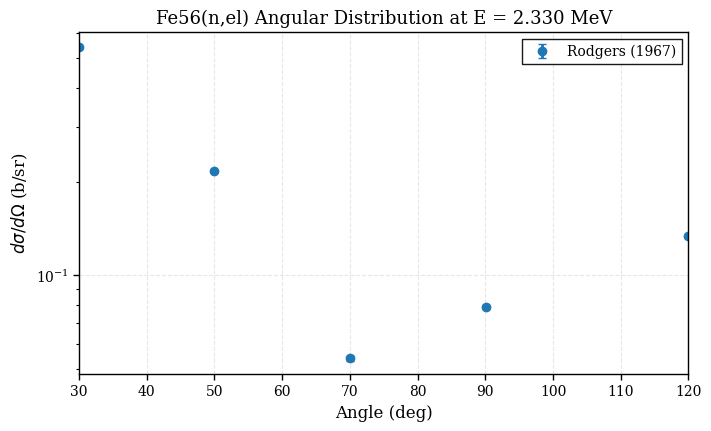

In [32]:
# Visualize angular distribution using PlotBuilder
plot_data = exp.to_plot_data(
    energy=closest_E,
    frame='LAB',
    angle_unit='deg',
    uncertainty=True,
    color='C0',
    marker='o',
    markersize=6,
    capsize=3
)

fig = (
    PlotBuilder(figsize=(10, 6))
    .add_data(plot_data)
    .set_labels(
        title=f'{exp.target}(n,el) Angular Distribution at E = {closest_E:.3f} MeV',
        x_label=r'Angle (deg)',
        y_label=r'$d\sigma/d\Omega$ (b/sr)'
    )
    .set_scales(log_y=True)
    .build()
)
plt.show()

## 5. Scenario 3: Search by Author

**Use case**: Find all experiments by a specific researcher, such as W.E. Kinney who made extensive measurements at ORNL.

This is useful for:
- Tracking a researcher's contributions
- Finding related measurements using consistent methodology
- Investigating systematic effects in a lab's data

In [33]:
# Query all experiments by Kinney (partial match on author name)
kinney_ids = db.query_dataset_ids(
    projectile="N",
    author="Kinney"
)

print(f"Found {len(kinney_ids)} experiments by Kinney")
print(f"\nDataset IDs: {kinney_ids[:10]}..." if len(kinney_ids) > 10 else f"\nDataset IDs: {kinney_ids}")

Found 147 experiments by Kinney

Dataset IDs: ['10105002', '10105006', '10105007', '10105009', '10106002', '10106003', '10106025', '10106026', '10107002', '10107006']...


In [34]:
# Build a summary table of Kinney's experiments
kinney_summary = []

for did in kinney_ids:
    meta = db.get_dataset_metadata(did)
    if meta:
        kinney_summary.append({
            'dataset_id': did,
            'target': meta.get('target', 'Unknown'),
            'year': meta.get('year'),
            'mt': meta.get('mt'),
            'ndat': meta.get('ndat'),  # Number of data points
        })

kinney_df = pd.DataFrame(kinney_summary)
print(f"\nKinney's experiments summary:")
kinney_df.sort_values(['target', 'mt'])


Kinney's experiments summary:


,dataset_id,target,year,mt,ndat
6,10106025,Al-27,1970,2,88
7,10106026,Al-27,1970,2,29
135,13034002,Al-27,1972,4,3
4,10106002,Al-27,1970,51,190
5,10106003,Al-27,1970,51,305
...,...,...,...,...,...
59,10286005,U-238,1973,9001,11180
50,10284002,W-0,1973,0,94
51,10284003,W-0,1973,0,60
52,10284004,W-0,1973,0,314


In [35]:
# Load one of Kinney's Fe-56 experiments
kinney_fe56_ids = kinney_df[kinney_df['target'].str.contains('Fe-56', case=False, na=False)]['dataset_id'].tolist()

if kinney_fe56_ids:
    kinney_exp = db.load_experiment(kinney_fe56_ids[0])
    print(f"Loaded: {kinney_exp.label}")
    print(f"Target: {kinney_exp.target}")
    print(f"Energies available: {len(kinney_exp.energies())}")
    print(f"Energy range: {kinney_exp.energies().min():.2f} - {kinney_exp.energies().max():.2f} MeV")
else:
    print("No Fe-56 experiments found for Kinney")

Loaded: Kinney (1968)
Target: Fe56
Energies available: 7
Energy range: 4.60 - 7.55 MeV


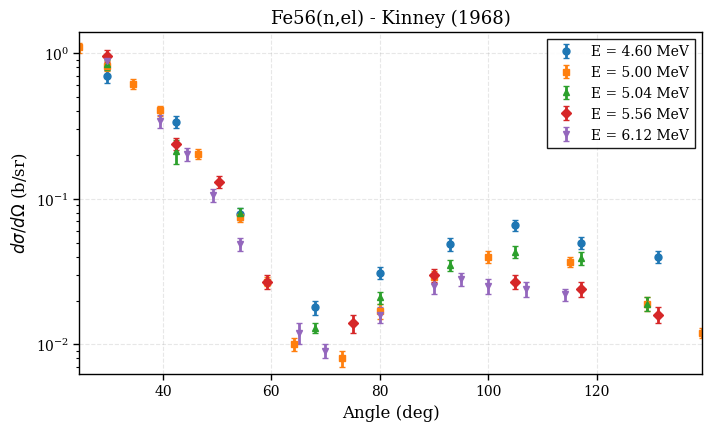

In [36]:
# Plot Kinney's data at multiple energies using PlotBuilder
if kinney_fe56_ids:
    builder = PlotBuilder(figsize=(10, 6))
    
    kinney_energies = kinney_exp.energies()
    # Select 5 energies spread across the range
    selected_energies = kinney_energies[::max(1, len(kinney_energies)//5)][:5]
    
    markers = ['o', 's', '^', 'D', 'v']
    colors = plt.cm.tab10.colors
    
    for i, E in enumerate(selected_energies):
        plot_data = kinney_exp.to_plot_data(
            energy=E,
            frame='LAB',
            angle_unit='deg',
            uncertainty=True,
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            markersize=5,
            capsize=2,
            label=f'E = {E:.2f} MeV'
        )
        builder.add_data(plot_data)
    
    fig = (
        builder
        .set_labels(
            title=f'{kinney_exp.target}(n,el) - {kinney_exp.label}',
            x_label='Angle (deg)',
            y_label=r'$d\sigma/d\Omega$ (b/sr)'
        )
        .set_scales(log_y=True)
        .set_legend(loc='best')
        .build()
    )
    plt.show()

## 6. Multi-Experiment Comparison at Same Energy

**Use case**: Compare angular distribution measurements from different research groups at the same energy.

This is critical for:
- Assessing measurement consistency
- Identifying outliers or systematic biases
- Building confidence in evaluated data

In [37]:
# Load all Fe-56 elastic scattering experiments
all_fe56_exp = db.query_angular_distributions(
    target_zaid=26056,
    mt=2,
    convert_to_objects=True
)

print(f"Loaded {len(all_fe56_exp)} Fe-56 elastic scattering experiments")

Loaded 16 Fe-56 elastic scattering experiments


In [38]:
# Find a common energy where multiple experiments have data
# Target: around 5 MeV
target_energy = 5.0  # MeV
tolerance = 0.5  # MeV

experiments_at_energy = []
for exp in all_fe56_exp:
    energies = exp.energies()
    # Find energies within tolerance
    matches = energies[np.abs(energies - target_energy) <= tolerance]
    if len(matches) > 0:
        closest = matches[np.argmin(np.abs(matches - target_energy))]
        experiments_at_energy.append((exp, closest))

print(f"Found {len(experiments_at_energy)} experiments with data near {target_energy} MeV (±{tolerance})")
for exp, E in experiments_at_energy:
    print(f"  {exp.label}: E = {E:.3f} MeV")

Found 3 experiments with data near 5.0 MeV (±0.5)
  Boschung (1971): E = 5.050 MeV
  Kinney (1968): E = 5.000 MeV
  Ramirez (2017): E = 4.900 MeV


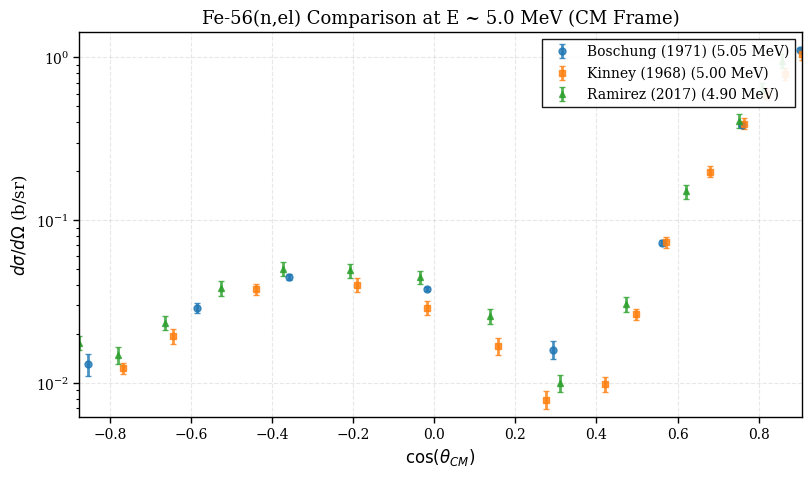

In [40]:
# Plot comparison of all experiments at similar energy using PlotBuilder
if experiments_at_energy:
    builder = PlotBuilder(figsize=(12, 7))
    
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    colors = plt.cm.tab10.colors
    
    for i, (exp, E) in enumerate(experiments_at_energy):
        plot_data = exp.to_plot_data(
            energy=E,
            frame='CM',  # Convert to CM for comparison
            angle_unit='cos',
            uncertainty=True,
            marker=markers[i % len(markers)],
            color=colors[i % len(colors)],
            markersize=5,
            capsize=2,
            alpha=0.8,
            label=f'{exp.label} ({E:.2f} MeV)'
        )
        if plot_data is not None:
            builder.add_data(plot_data)
    
    fig = (
        builder
        .set_labels(
            title=f'Fe-56(n,el) Comparison at E ~ {target_energy} MeV (CM Frame)',
            x_label=r'$\cos(\theta_{CM})$',
            y_label=r'$d\sigma/d\Omega$ (b/sr)'
        )
        .set_scales(log_y=True)
        .set_legend(loc='upper right')
        .build()
    )
    plt.show()

## 7. Historical vs Recent Data Comparison

**Use case**: Compare measurements from different eras to understand how experimental techniques have evolved.

This helps assess:
- Whether older data is still reliable
- Improvements in measurement precision
- Systematic differences between decades

In [41]:
# Query experiments from different time periods

# Historical: 1965-1985
historical_ids = db.query_dataset_ids(
    target_zaid=26056,
    mt=2,
    year_min=1965,
    year_max=1985
)
print(f"Historical experiments (1965-1985): {len(historical_ids)}")

# Recent: 2000-2025
recent_ids = db.query_dataset_ids(
    target_zaid=26056,
    mt=2,
    year_min=2000,
    year_max=2025
)
print(f"Recent experiments (2000-2025): {len(recent_ids)}")

Historical experiments (1965-1985): 12
Recent experiments (2000-2025): 4


In [42]:
# Build summary table
def build_era_summary(dataset_ids, db):
    summary = []
    for did in dataset_ids:
        meta = db.get_dataset_metadata(did)
        if meta:
            summary.append({
                'dataset_id': did,
                'author': meta.get('author', 'Unknown'),
                'year': meta.get('year'),
                'ndat': meta.get('ndat', 0),
            })
    return pd.DataFrame(summary)

historical_df = build_era_summary(historical_ids, db)
recent_df = build_era_summary(recent_ids, db)

print("Historical Experiments (1965-1985):")
print(historical_df.sort_values('year'))
print(f"\nRecent Experiments (2000-2025):")
print(recent_df.sort_values('year'))

Historical Experiments (1965-1985):
   dataset_id      author  year  ndat
2    11276009     Rodgers  1967     5
5    20482005        Cabe  1967    63
6    20482006        Cabe  1967    21
3    11708006      Kinney  1968    85
0    10037024    Boschung  1971    19
9   400750022     Morozov  1972    17
10  400750021     Morozov  1972    17
11   40417003   Tutubalin  1973    16
7    30463020  Schweitzer  1978    12
8    30463022  Schweitzer  1978     6
1    10958004     El-kadi  1982   104
4    12862003     Mellema  1983    82

Recent Experiments (2000-2025):
  dataset_id          author  year  ndat
1   22987002           Oehrn  2008    36
2   22987005           Oehrn  2008     1
3   23059003  Sagrado garcia  2011     4
0   14462002         Ramirez  2017   192


In [54]:
# Compare data from different eras at similar energy
comparison_energy = 1.5  # MeV
energy_tolerance = 1.0  # MeV

def find_experiment_at_energy(dataset_ids, db, target_E, tolerance):
    """Find first experiment with data near target energy."""
    for did in dataset_ids:
        try:
            exp = db.load_experiment(did)
            energies = exp.energies()
            matches = energies[np.abs(energies - target_E) <= tolerance]
            if len(matches) > 0:
                closest = matches[np.argmin(np.abs(matches - target_E))]
                return exp, closest
        except Exception:
            continue
    return None, None

historical_exp, historical_E = find_experiment_at_energy(historical_ids, db, comparison_energy, energy_tolerance)
recent_exp, recent_E = find_experiment_at_energy(recent_ids, db, comparison_energy, energy_tolerance)

if historical_exp:
    print(f"Historical: {historical_exp.label} at E = {historical_E:.2f} MeV")
if recent_exp:
    print(f"Recent: {recent_exp.label} at E = {recent_E:.2f} MeV")

Historical: Rodgers (1967) at E = 2.33 MeV
Recent: Ramirez (2017) at E = 1.50 MeV


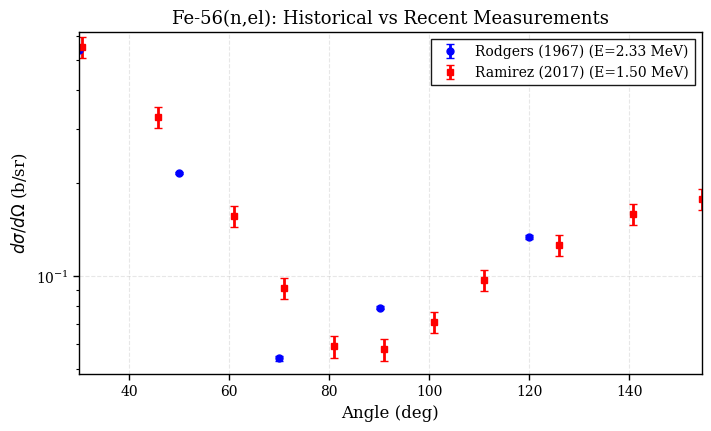

In [55]:
# Plot historical vs recent comparison using PlotBuilder
if historical_exp and recent_exp:
    builder = PlotBuilder(figsize=(10, 6))
    
    # Historical data
    plot_hist = historical_exp.to_plot_data(
        energy=historical_E,
        frame='LAB',
        angle_unit='deg',
        uncertainty=True,
        color='blue',
        marker='o',
        markersize=5,
        capsize=3,
        label=f'{historical_exp.label} (E={historical_E:.2f} MeV)'
    )
    builder.add_data(plot_hist)
    
    # Recent data
    plot_recent = recent_exp.to_plot_data(
        energy=recent_E,
        frame='LAB',
        angle_unit='deg',
        uncertainty=True,
        color='red',
        marker='s',
        markersize=5,
        capsize=3,
        label=f'{recent_exp.label} (E={recent_E:.2f} MeV)'
    )
    builder.add_data(plot_recent)
    
    fig = (
        builder
        .set_labels(
            title='Fe-56(n,el): Historical vs Recent Measurements',
            x_label='Angle (deg)',
            y_label=r'$d\sigma/d\Omega$ (b/sr)'
        )
        .set_scales(log_y=True)
        .set_legend(loc='best')
        .build()
    )
    plt.show()

## 8. Data Export for External Analysis

**Use case**: Export EXFOR data to CSV or Excel for use in other analysis tools (Monte Carlo codes, spreadsheets, etc.).

In [56]:
# Export a single experiment to CSV
if historical_exp:
    df_export = historical_exp.to_dataframe()
    
    # Add metadata columns
    df_export['experiment'] = f"{historical_exp.entry}{historical_exp.subentry}"
    df_export['author'] = historical_exp.label
    df_export['target'] = historical_exp.target
    
    # Save to CSV
    csv_filename = f"{historical_exp.target}_{historical_exp.entry}{historical_exp.subentry}_data.csv"
    df_export.to_csv(csv_filename, index=False)
    print(f"Exported to: {csv_filename}")
    print(f"\nPreview:")
    df_export.head()

Exported to: Fe56_11276009_data.csv

Preview:


In [57]:
# Batch export: Combine multiple experiments into one file
all_data = []

for exp, E in experiments_at_energy[:5]:  # First 5 experiments
    df = exp.to_dataframe(energy=E)
    if len(df) > 0:
        df['dataset_id'] = f"{exp.entry}{exp.subentry}"
        df['author'] = exp.label
        df['target'] = exp.target
        all_data.append(df)

if all_data:
    combined_df = pd.concat(all_data, ignore_index=True)
    combined_df.to_csv('fe56_multi_experiment_comparison.csv', index=False)
    print(f"Combined export: {len(combined_df)} data points from {len(all_data)} experiments")
    print(f"\nSaved to: fe56_multi_experiment_comparison.csv")
    print(f"\nPreview:")
    combined_df.head(10)

Combined export: 47 data points from 3 experiments

Saved to: fe56_multi_experiment_comparison.csv

Preview:


## 9. Frame Conversions (LAB vs CM)

**Use case**: Convert between Laboratory (LAB) and Center-of-Mass (CM) reference frames.

This is important because:
- EXFOR data is often reported in LAB frame
- Nuclear models often work in CM frame
- Comparison with evaluated data (ENDF) requires frame consistency

In [58]:
# Check the original frame of an experiment
if historical_exp:
    print(f"Experiment: {historical_exp.label}")
    print(f"Original frame: {historical_exp.angle_frame}")
    print(f"Target mass: {historical_exp.target_mass} amu")

Experiment: Rodgers (1967)
Original frame: LAB
Target mass: 55.934936 amu


In [59]:
# Convert from LAB to CM frame
if historical_exp and historical_exp.angle_frame == 'LAB':
    # Create a CM-converted copy (doesn't modify original)
    exp_cm = historical_exp.convert_to_cm(inplace=False)
    
    print(f"Original frame: {historical_exp.angle_frame}")
    print(f"Converted frame: {exp_cm.angle_frame}")

Original frame: LAB
Converted frame: CM


C:\Users\Usuario\AppData\Local\Temp\ipykernel_68004\1297033563.py:48: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


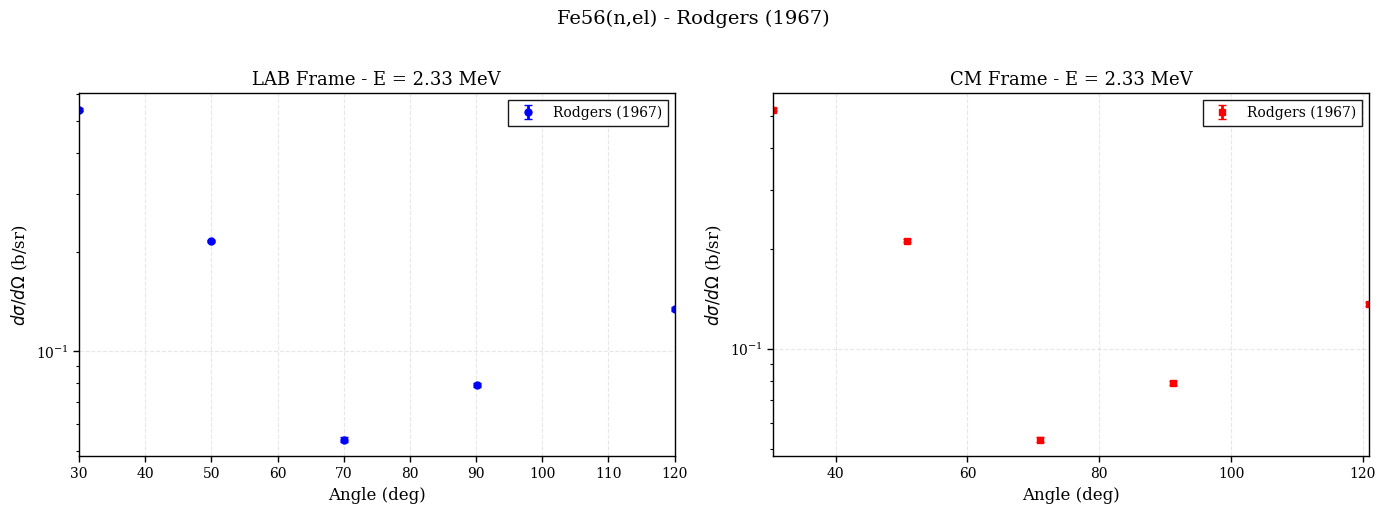


Note: In CM frame, angles are shifted forward and cross sections are scaled.
Maximum LAB angle: 120.0 deg
Maximum CM angle:  120.9 deg


In [60]:
# Plot side-by-side comparison of LAB vs CM using PlotBuilder
if historical_exp and historical_E:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # LAB frame
    plot_lab = historical_exp.to_plot_data(
        energy=historical_E,
        frame='LAB',
        angle_unit='deg',
        uncertainty=True,
        color='blue',
        marker='o',
        markersize=5,
        capsize=3
    )
    builder1 = PlotBuilder(ax=ax1)
    builder1.add_data(plot_lab)
    builder1.set_labels(
        title=f'LAB Frame - E = {historical_E:.2f} MeV',
        x_label='Angle (deg)',
        y_label=r'$d\sigma/d\Omega$ (b/sr)'
    )
    builder1.set_scales(log_y=True)
    builder1.build()
    
    # CM frame
    plot_cm = historical_exp.to_plot_data(
        energy=historical_E,
        frame='CM',
        angle_unit='deg',
        uncertainty=True,
        color='red',
        marker='s',
        markersize=5,
        capsize=3
    )
    builder2 = PlotBuilder(ax=ax2)
    builder2.add_data(plot_cm)
    builder2.set_labels(
        title=f'CM Frame - E = {historical_E:.2f} MeV',
        x_label='Angle (deg)',
        y_label=r'$d\sigma/d\Omega$ (b/sr)'
    )
    builder2.set_scales(log_y=True)
    builder2.build()
    
    fig.suptitle(f'{historical_exp.target}(n,el) - {historical_exp.label}', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Get angle info for comparison
    df_lab = historical_exp.to_dataframe(energy=historical_E)
    exp_cm = historical_exp.convert_to_cm(inplace=False)
    df_cm = exp_cm.to_dataframe(energy=historical_E)
    
    print(f"\nNote: In CM frame, angles are shifted forward and cross sections are scaled.")
    print(f"Maximum LAB angle: {df_lab['angle'].max():.1f} deg")
    print(f"Maximum CM angle:  {df_cm['angle'].max():.1f} deg")

## 10. Additional Nuclear Engineer Scenarios

### 10.1 Inelastic Scattering Data

Angular distributions exist for inelastic scattering to excited states. MT numbers for inelastic:
- MT=51: First excited state
- MT=52: Second excited state
- MT=91: Continuum inelastic

In [61]:
# Query inelastic scattering to first excited state (MT=51)
inelastic_exp = db.list_experiments(target="Fe56", mt=51)
print(f"Fe-56 inelastic (MT=51) experiments: {len(inelastic_exp)}")
inelastic_exp

Fe-56 inelastic (MT=51) experiments: 56


,dataset_id,author,year,energy_min,energy_max
0,11711003,Stelson,1952,1.8700,1.8700
1,113960122,Cranberg,1956,2.2500,2.4500
2,11694004,Weddell,1956,6.5000,6.5000
3,21398002,Naggiar,1957,1.5000,1.6600
4,11496005,Bredin,1964,1.9500,1.9500
...,...,...,...,...,...
51,22128013,Olsson,1990,21.6000,21.6000
52,22403003,Schmidt,1994,0.1200,0.1360
53,14462003,Ramirez,2017,1.5000,7.9600
54,23365008,Pirovano,2019,2.0019,6.0124


### 10.2 Isotope Comparison

Compare angular distributions across different iron isotopes to study mass dependence.

In [62]:
# Compare experiment counts for different iron isotopes
isotope_counts = {}
for target in iron_targets:
    exp_df = db.list_experiments(target=target, mt=2)
    isotope_counts[target] = len(exp_df)

print("Iron isotope elastic scattering experiments:")
for target, count in sorted(isotope_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {target}: {count} experiments")

Iron isotope elastic scattering experiments:
  Fe-0: 121 experiments
  Fe-56: 18 experiments
  Fe-54: 16 experiments
  Fe-57: 0 experiments
  Fe-58: 0 experiments
  Fe-cmp: 0 experiments


### 10.3 Finding Benchmark-Quality Data

For nuclear model validation, we often need high-quality data with:
- Many data points (good angular coverage)
- Small uncertainties
- Multiple energies

In [63]:
# Find experiments with the most data points (likely higher quality)
all_experiments = db.list_experiments(target="Fe56", mt=2)

# Load each and count total data points
exp_quality = []
for _, row in all_experiments.iterrows():
    try:
        exp = db.load_experiment(row['dataset_id'])
        df = exp.to_dataframe()
        exp_quality.append({
            'dataset_id': row['dataset_id'],
            'author': row['author'],
            'year': row['year'],
            'n_energies': len(exp.energies()),
            'n_total_points': len(df),
            'energy_range': f"{row['energy_min']:.2f}-{row['energy_max']:.2f} MeV"
        })
    except Exception as e:
        continue

quality_df = pd.DataFrame(exp_quality).sort_values('n_total_points', ascending=False)
print("Experiments ranked by number of data points:")
quality_df.head(10)

Experiments ranked by number of data points:


,dataset_id,author,year,n_energies,n_total_points,energy_range
13,13511004,Perey,1991,6226,37362,0.04-0.85 MeV
17,14462002,Ramirez,2017,15,192,1.30-7.96 MeV
10,10958004,El-kadi,1982,4,104,7.96-13.92 MeV
3,11708006,Kinney,1968,7,85,0.03-0.05 MeV
11,12862003,Mellema,1983,3,82,11.00-26.00 MeV
0,20482005,Cabe,1967,6,63,0.02-0.04 MeV
14,22987002,Oehrn,2008,1,36,96.00-96.00 MeV
1,20482006,Cabe,1967,6,21,0.02-0.04 MeV
4,10037024,Boschung,1971,2,19,0.01-0.01 MeV
5,400750022,Morozov,1972,1,17,1.80-1.80 MeV


## 11. Summary and Quick Reference

### Key Functions

| Function | Purpose |
|----------|--------|
| `X4ProDatabase()` | Connect to EXFOR database |
| `db.list_targets()` | List all available isotopes |
| `db.list_experiments(target, mt)` | List experiments for a target |
| `db.query_dataset_ids(...)` | Query with multiple filters (author, year, energy) |
| `db.load_experiment(id)` | Load specific experiment |
| `db.get_dataset_metadata(id)` | Get experiment metadata |
| `exp.energies()` | Get available energies |
| `exp.to_dataframe()` | Convert to pandas DataFrame |
| `exp.convert_to_cm()` | Convert LAB to CM frame |

### Target Notation Formats

```python
# All equivalent ways to specify Fe-56:
target = "Fe56"      # Symbol + mass
target = 26056       # ZAID (integer)
target = "Fe-56"     # With hyphen
target = "26-FE-56"  # EXFOR notation

# Natural element:
target = "Fe-0"      # Natural iron
target = "Fe"        # Also works
target = 26000       # ZAID for natural
```

### Common MT Numbers

| MT | Reaction |
|----|----------|
| 2  | Elastic scattering |
| 51 | Inelastic to 1st excited state |
| 52 | Inelastic to 2nd excited state |
| 91 | Continuum inelastic |

In [64]:
# Close database connection when done
db.close()
print("Database connection closed.")

Database connection closed.
